# One-Time Baby Shopper Analysis
### Profile · Segment · Win-Back Scoring

**Definition:** Customers with exactly **1 shopping day** in the 12-month observation window.

**Why a separate analysis?** One-time shoppers cannot be analysed with repeat-shopper
features (no gaps, no episodes, no trajectory). Their entire behavioral signal lives in
a single visit: what they bought, how much they spent, what mix of categories, and when.

**Pipeline:**
1. Load Phase 1 outputs & isolate one-time shoppers
2. Feature engineering — 8 single-visit behavioral features
3. K-Means clustering — segment by basket behavior
4. Segment cards — profile each group
5. Win-back scoring — probability of conversion to repeat shopper
6. Visualisations
7. Strategic recommendations
8. Output files


---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C7BB6','#D7191C','#1A9641','#FDAE61','#762A83','#F46D43']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi':130,'axes.titlesize':12,
                     'axes.titleweight':'bold','figure.titlesize':13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

RANDOM_STATE    = 42
BULK_PERCENTILE = 0.90   # consistent with Phase 1
print("Setup complete.")


Setup complete.


---
## 2. Load & Isolate One-Time Shoppers

In [2]:
# ── 2.1 Load Phase 1 master profile ──────────────────────────────────────────
profile = pd.read_parquet('baby_shopper_profiles_phase1.parquet')

print(f"Full profile: {profile.shape[0]:,} customers")
print()
print("Shopper type split:")
type_counts = profile['shopper_type'].value_counts()
for t, n in type_counts.items():
    print(f"  {t:12s}: {n:,} ({n/len(profile)*100:.1f}%)")


Full profile: 1,483,837 customers

Shopper type split:
  One-Time    : 854,617 (57.6%)
  Repeat      : 629,220 (42.4%)


In [3]:
# ── 2.2 Filter to one-time shoppers ──────────────────────────────────────────
# Definition: total_transactions_12m == 1
# (one shopping day in the observation window)

ots = profile[profile['total_transactions_12m'] == 1].copy().reset_index(drop=True)

print(f"One-time shoppers : {len(ots):,}")
print(f"  Min transactions: {ots['total_transactions_12m'].min()}")
print(f"  Max transactions: {ots['total_transactions_12m'].max()}")
print()

# Sanity check — all should be flagged as One-Time already
type_check = ots['shopper_type'].value_counts()
print(f"shopper_type check: {type_check.to_dict()}")


One-time shoppers : 492,394
  Min transactions: 1.0
  Max transactions: 1.0

shopper_type check: {'One-Time': 492394}


In [4]:
# ── 2.3 Load raw transactions for one-time shoppers ───────────────────────────
# We need row-level data to compute basket composition and category features.


raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")

for col in ['department_cleaned','subdepartment_cleaned','subclass']:
    raw[col] = raw[col].str.lower().str.strip()

raw['header_tran_date'] = raw['header_tran_date'].str.replace('Sept','Sep', regex=False)
raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
raw = raw.dropna(subset=['date','gcr_persistent_id'])

PROMO_FILTERS = [
    ('subclass',              'md promo'),
    ('subdepartment_cleaned', 'iw promotions'),
    ('subdepartment_cleaned', 'iaf clearance'),
    ('subdepartment_cleaned', 'iaf promotions'),
]
for col, val in PROMO_FILTERS:
    raw = raw[raw[col] != val]

SNAPSHOT_DATE  = raw['date'].max()
WINDOW_START   = SNAPSHOT_DATE - pd.DateOffset(months=12)
raw['date']    = pd.to_datetime(raw['date'])
raw            = raw[raw['date'] >= WINDOW_START].copy()
raw['customer_id'] = pd.factorize(raw['gcr_persistent_id'])[0]

# Filter to one-time shopper IDs
ots_ids = set(ots['customer_id'].values)
seq = raw[raw['customer_id'].isin(ots_ids)].copy()
seq = seq.sort_values(['customer_id','date']).reset_index(drop=True)

print(f"Raw rows for one-time shoppers : {len(seq):,}")
print(f"Unique customers confirmed     : {seq['customer_id'].nunique():,}")
print(f"Snapshot date                  : {SNAPSHOT_DATE.date()}")


Raw rows for one-time shoppers : 492,394
Unique customers confirmed     : 492,394
Snapshot date                  : 2025-12-31


---
## 3. Feature Engineering

One-time shoppers only have a single visit — so all features derive from that one occasion.

| # | Feature | What it captures |
|---|---------|-----------------|
| 1 | `total_spend` | How much they spent on the visit |
| 2 | `total_units` | How many items they bought |
| 3 | `spend_per_unit` | Average price per unit — proxy for product quality tier |
| 4 | `category_breadth` | How many distinct subdepts in the basket |
| 5 | `top_category_share` | Concentration — dominated by one category vs spread |
| 6 | `is_bulk_visit` | Did they buy unusually high volume (p90 threshold) |
| 7 | `recency_days` | How long ago was the visit (days before snapshot) |
| 8 | `visit_month_index` | Month index of visit — captures seasonal timing |


In [5]:
# ── Feature 1-4: Spend, units, spend/unit, category breadth ───────────────────
visit_stats = (
    seq.groupby('customer_id')
       .agg(
           total_spend      = ('total_sales',            'sum'),
           total_units      = ('total_units',            'sum'),
           category_breadth = ('subdepartment_cleaned',  'nunique'),
           visit_date       = ('date',                   'first'),
       )
       .reset_index()
)
visit_stats['spend_per_unit'] = (
    visit_stats['total_spend'] / visit_stats['total_units'].clip(lower=1)
)

print("Features 1-4:")
visit_stats[['total_spend','total_units','spend_per_unit','category_breadth']].describe().round(2)


Features 1-4:


,total_spend,total_units,spend_per_unit,category_breadth
count,492394.000,492394.000,492394.000,492394.000
mean,651.040,1.230,571.600,1.000
std,1214.730,0.950,1151.250,0.000
min,17.750,1.000,17.750,1.000
25%,224.500,1.000,199.000,1.000
50%,410.000,1.000,359.200,1.000
75%,689.750,1.000,599.000,1.000
max,87297.300,312.000,54999.000,1.000


In [6]:
# ── Feature 5: Top category share ────────────────────────────────────────────
# Share of total units from the most-purchased subdept in the basket

subdept_units = (
    seq.groupby(['customer_id','subdepartment_cleaned'])['total_units']
       .sum()
       .reset_index(name='subdept_units')
)
cust_total_units = (
    seq.groupby('customer_id')['total_units']
       .sum()
       .reset_index(name='total_units_check')
)
subdept_units = subdept_units.merge(cust_total_units, on='customer_id')
subdept_units['unit_share'] = (
    subdept_units['subdept_units'] / subdept_units['total_units_check'].clip(lower=1)
)

# Top category share = max unit share per customer
top_cat_share = (
    subdept_units.groupby('customer_id')['unit_share']
                 .max()
                 .rename('top_category_share')
                 .reset_index()
)

# Top category name
top_cat_name = (
    subdept_units.sort_values('unit_share', ascending=False)
                 .drop_duplicates('customer_id')[['customer_id','subdepartment_cleaned']]
                 .rename(columns={'subdepartment_cleaned':'top_category'})
)

print("Feature 5 — top_category_share:")
print(top_cat_share['top_category_share'].describe().round(3))


Feature 5 — top_category_share:
count   492394.000
mean         1.000
std          0.000
min          1.000
25%          1.000
50%          1.000
75%          1.000
max          1.000
Name: top_category_share, dtype: float64


In [7]:
# ── Feature 6: Bulk visit flag ────────────────────────────────────────────────
# Is this visit in the top 10% of total units purchased across all one-time shoppers?
# Consistent with Phase 1 bulk threshold definition.

bulk_threshold = visit_stats['total_units'].quantile(BULK_PERCENTILE)
visit_stats['is_bulk_visit'] = (visit_stats['total_units'] >= bulk_threshold).astype(int)

print(f"Bulk threshold (p{int(BULK_PERCENTILE*100)}): {bulk_threshold:.0f} units")
print(f"Bulk visitors: {visit_stats['is_bulk_visit'].sum():,} ({visit_stats['is_bulk_visit'].mean()*100:.1f}%)")


Bulk threshold (p90): 2 units
Bulk visitors: 85,689 (17.4%)


In [8]:
# ── Features 7-8: Recency and visit month index ───────────────────────────────
visit_stats['recency_days'] = (SNAPSHOT_DATE - visit_stats['visit_date']).dt.days

# Month index: months before snapshot (0 = most recent month, 11 = 12 months ago)
visit_stats['visit_year_month'] = visit_stats['visit_date'].dt.to_period('M')
snap_ym = SNAPSHOT_DATE.year * 12 + SNAPSHOT_DATE.month
visit_stats['visit_month_index'] = (
    snap_ym
    - visit_stats['visit_date'].dt.year * 12
    - visit_stats['visit_date'].dt.month
)

print("Features 7-8 — recency_days & visit_month_index:")
print(visit_stats[['recency_days','visit_month_index']].describe().round(1))


Features 7-8 — recency_days & visit_month_index:
       recency_days  visit_month_index
count    492394.000         492394.000
mean        145.900              4.300
std         112.700              3.700
min           0.000              0.000
25%          33.000              1.000
50%         136.000              4.000
75%         230.000              7.000
max         364.000             11.000


In [9]:
# ── Assemble master one-time shopper feature table ───────────────────────────
ots = (
    ots.merge(visit_stats[['customer_id','total_spend','total_units',
                            'spend_per_unit','category_breadth','is_bulk_visit',
                            'recency_days','visit_month_index','visit_date',
                            'visit_year_month']],
              on='customer_id', how='left')
       .merge(top_cat_share, on='customer_id', how='left')
       .merge(top_cat_name,  on='customer_id', how='left')
)

# Journey stage from top_category (consistent with Phase 1)
STAGE_MAP = {
    'newborn essential 0-12mos': 'Early Care',
    'nursing & feeding':         'Early Care',
    'toiletries':                'Daily Care',
    'food and supplements':      'Growth',
    'clothing':                  'Lifestyle',
    'carriers & wheeled goods':  'Mobility',
}
ots['journey_stage'] = ots['top_category'].map(STAGE_MAP).fillna('Other')

# Resolve column name conflicts: Phase 1 profile also has total_spend_12m
# For one-time shoppers total_spend_12m == total_spend (one visit). Alias for clarity.
if 'total_spend_12m' in ots.columns:
    ots = ots.drop(columns=['total_spend_12m'])
ots = ots.rename(columns={'total_spend':'visit_spend','total_units':'visit_units'})

# Feature list for clustering
OTS_FEATURES = [
    'visit_spend',
    'visit_units',
    'spend_per_unit',
    'category_breadth',
    'top_category_share',
    'is_bulk_visit',
    'recency_days',
    'visit_month_index',
]

print(f"One-time shopper profile: {ots.shape[0]:,} rows × {ots.shape[1]} cols")
ots[OTS_FEATURES].describe().T[['mean','std','min','50%','max']].round(2)


One-time shopper profile: 492,394 rows × 80 cols


,mean,std,min,50%,max
visit_spend,651.040,1214.730,17.750,410.000,87297.300
visit_units,1.230,0.950,1.000,1.000,312.000
spend_per_unit,571.600,1151.250,17.750,359.200,54999.000
category_breadth,1.000,0.000,1.000,1.000,1.000
top_category_share,1.000,0.000,1.000,1.000,1.000
is_bulk_visit,0.170,0.380,0.000,0.000,1.000
recency_days,145.920,112.680,0.000,136.000,364.000
visit_month_index,4.310,3.660,0.000,4.000,11.000


---
## 4. Descriptive Profiling

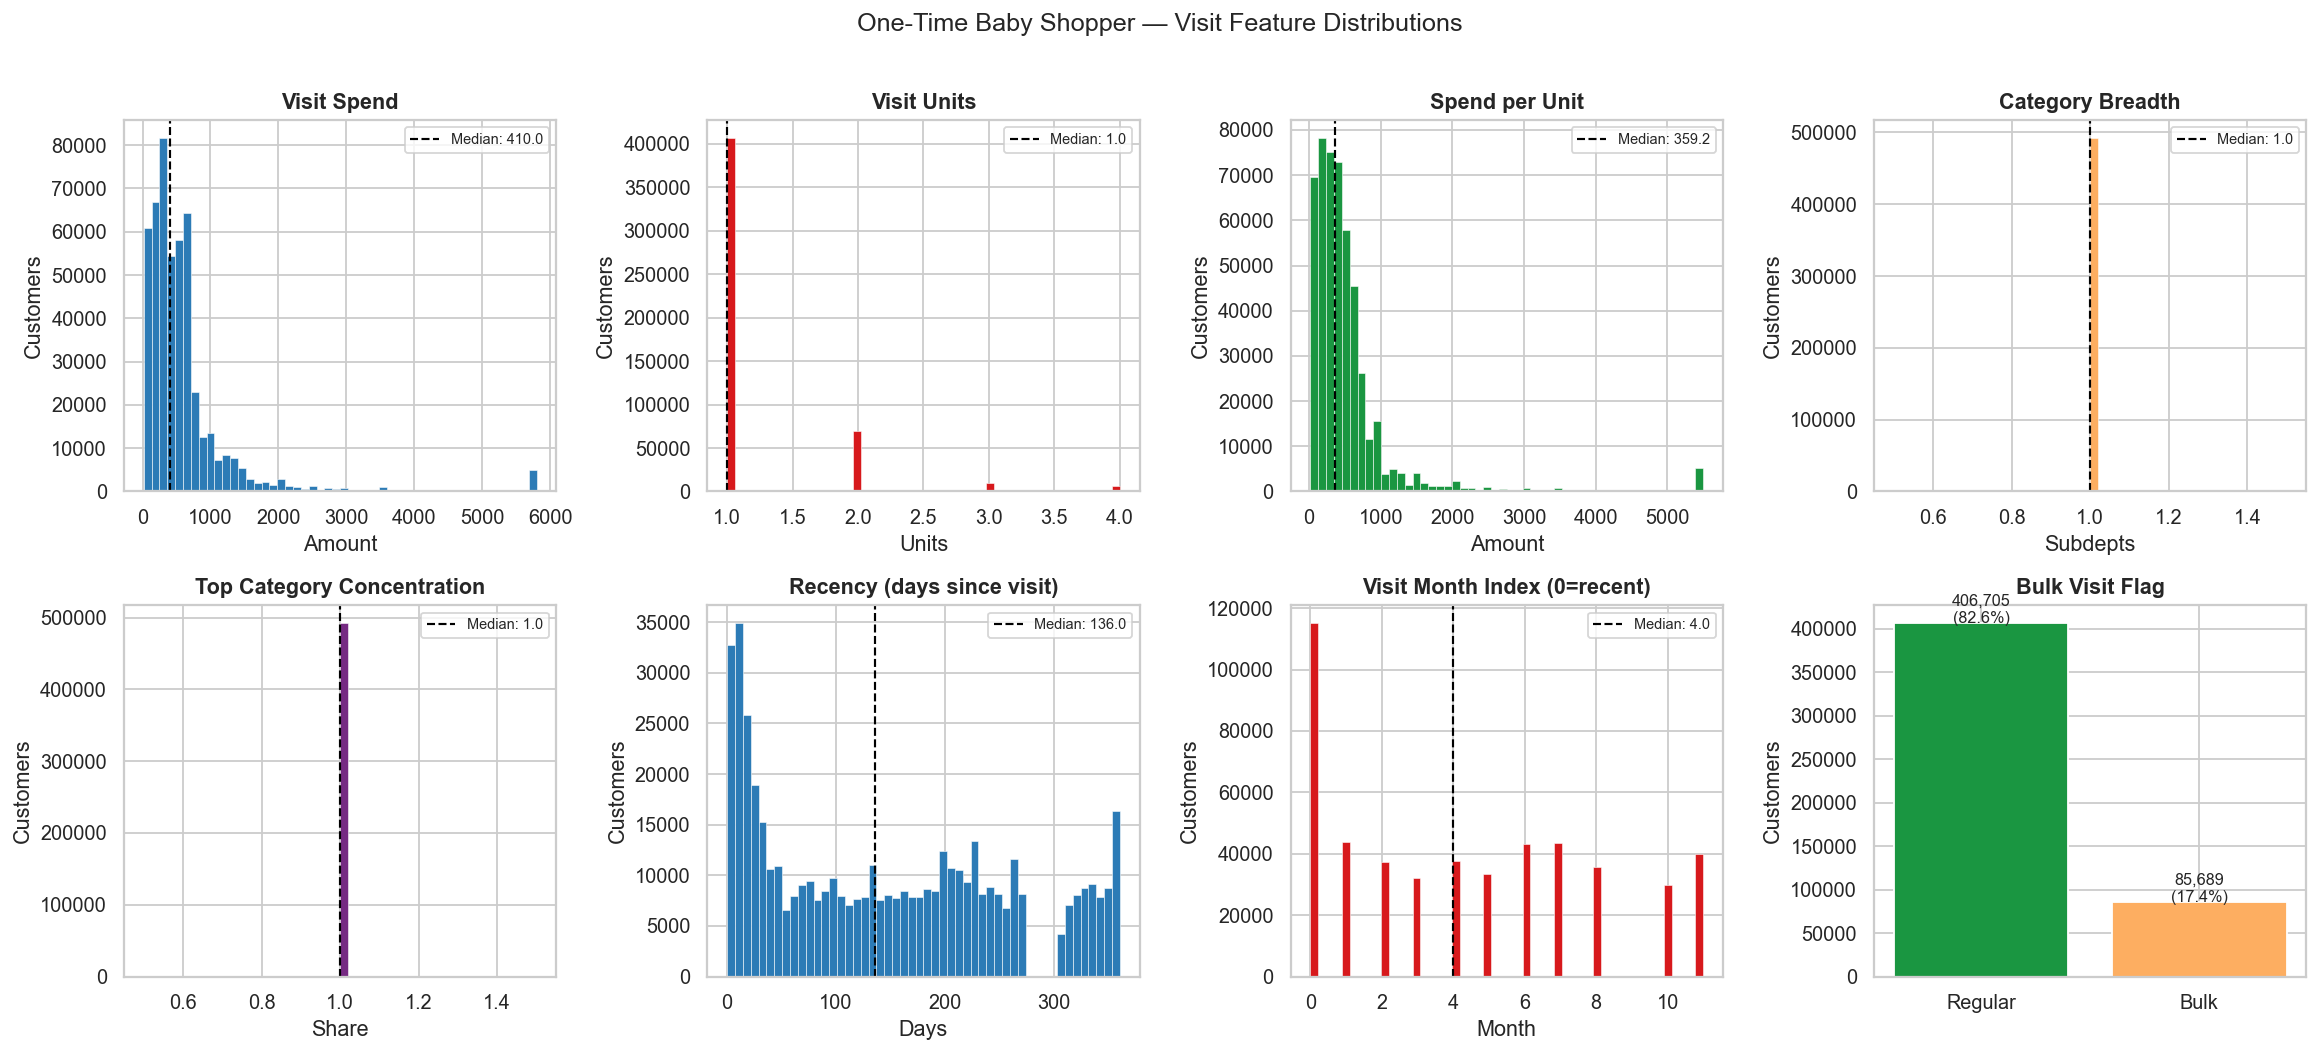

In [10]:
# ── 4.1 Core distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('One-Time Baby Shopper — Visit Feature Distributions', fontsize=14, y=1.01)

def hist(ax, series, title, xlabel, color, pct=0.99):
    data = series.dropna()
    clip_val = data.quantile(pct)
    ax.hist(data.clip(upper=clip_val), bins=50, color=color,
            edgecolor='white', linewidth=0.3)
    med = data.median()
    ax.axvline(med, color='black', linestyle='--', lw=1.2,
               label=f'Median: {med:.1f}')
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('Customers')
    ax.legend(fontsize=8)

hist(axes[0,0], ots['visit_spend'],        'Visit Spend',             'Amount',  PALETTE[0])
hist(axes[0,1], ots['visit_units'],        'Visit Units',             'Units',   PALETTE[1])
hist(axes[0,2], ots['spend_per_unit'],     'Spend per Unit',          'Amount',  PALETTE[2])
hist(axes[0,3], ots['category_breadth'],   'Category Breadth',        'Subdepts',PALETTE[3])
hist(axes[1,0], ots['top_category_share'], 'Top Category Concentration','Share', PALETTE[4])
hist(axes[1,1], ots['recency_days'],       'Recency (days since visit)','Days',  PALETTE[0])
hist(axes[1,2], ots['visit_month_index'],  'Visit Month Index (0=recent)','Month',PALETTE[1])

# Bulk flag as bar chart
bulk_counts = ots['is_bulk_visit'].value_counts().sort_index()
axes[1,3].bar(['Regular','Bulk'], bulk_counts.values,
              color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[1,3].set_title('Bulk Visit Flag')
axes[1,3].set_ylabel('Customers')
for i, v in enumerate(bulk_counts.values):
    axes[1,3].text(i, v + 10, f'{v:,}\n({v/len(ots)*100:.1f}%)',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('OTS_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


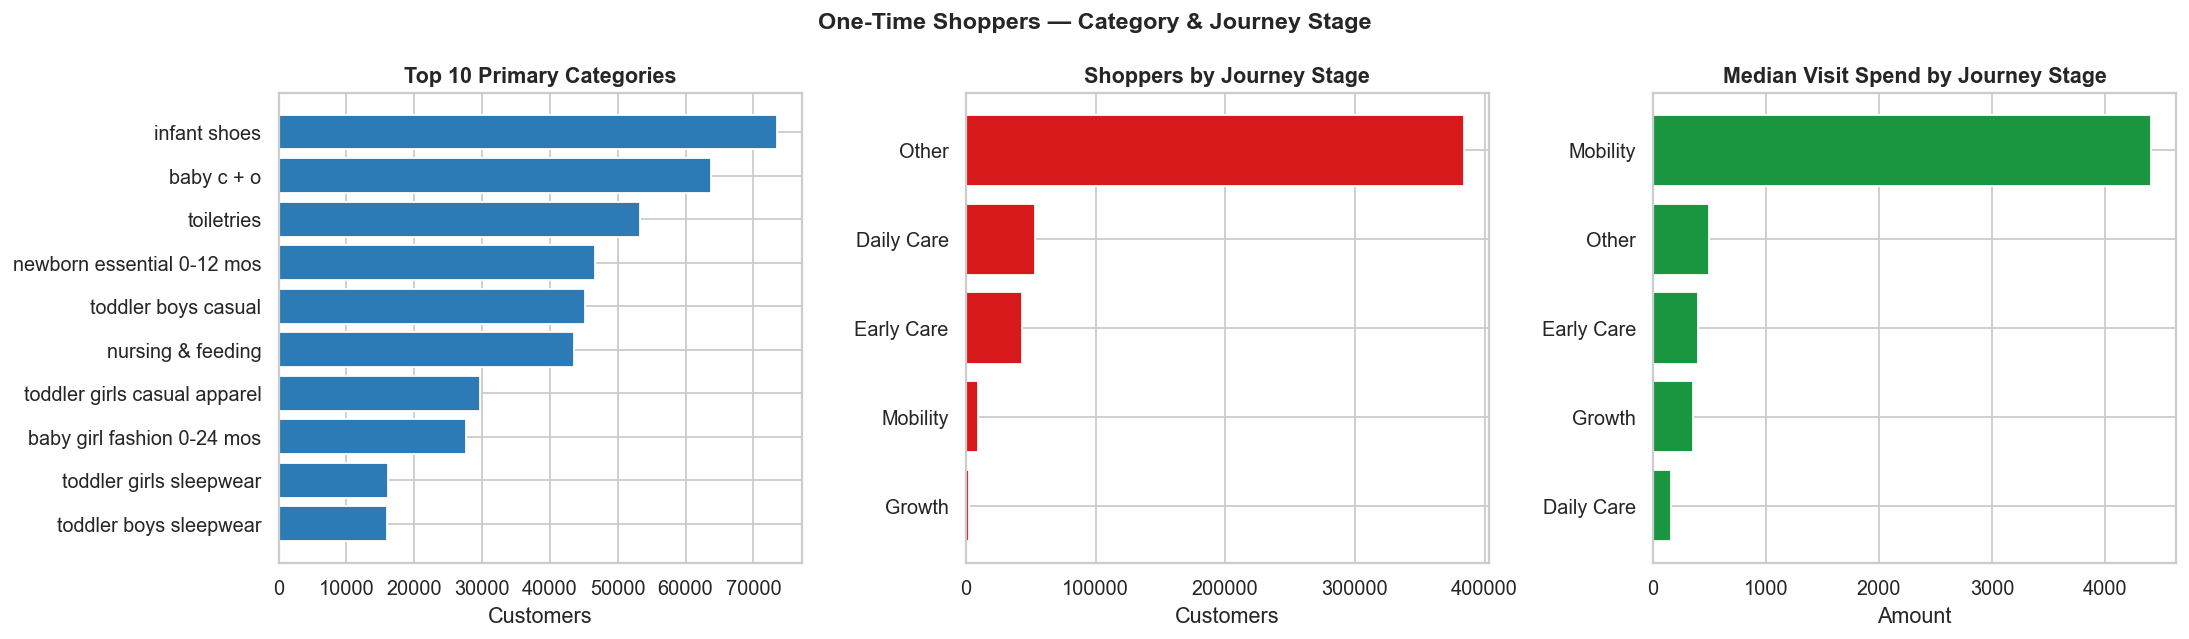

In [11]:
# ── 4.2 Top categories and journey stage breakdown ────────────────────────────
cat_counts  = ots['top_category'].value_counts().head(10)
stage_spend = ots.groupby('journey_stage')['visit_spend'].median().sort_values(ascending=False)
stage_count = ots['journey_stage'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('One-Time Shoppers — Category & Journey Stage', fontweight='bold')

axes[0].barh(cat_counts.index, cat_counts.values,
             color=PALETTE[0], edgecolor='white')
axes[0].set_title('Top 10 Primary Categories')
axes[0].set_xlabel('Customers'); axes[0].invert_yaxis()

axes[1].barh(stage_count.index, stage_count.values,
             color=PALETTE[1], edgecolor='white')
axes[1].set_title('Shoppers by Journey Stage')
axes[1].set_xlabel('Customers'); axes[1].invert_yaxis()

axes[2].barh(stage_spend.index, stage_spend.values,
             color=PALETTE[2], edgecolor='white')
axes[2].set_title('Median Visit Spend by Journey Stage')
axes[2].set_xlabel('Amount'); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('OTS_02_categories.png', dpi=150, bbox_inches='tight')
plt.show()


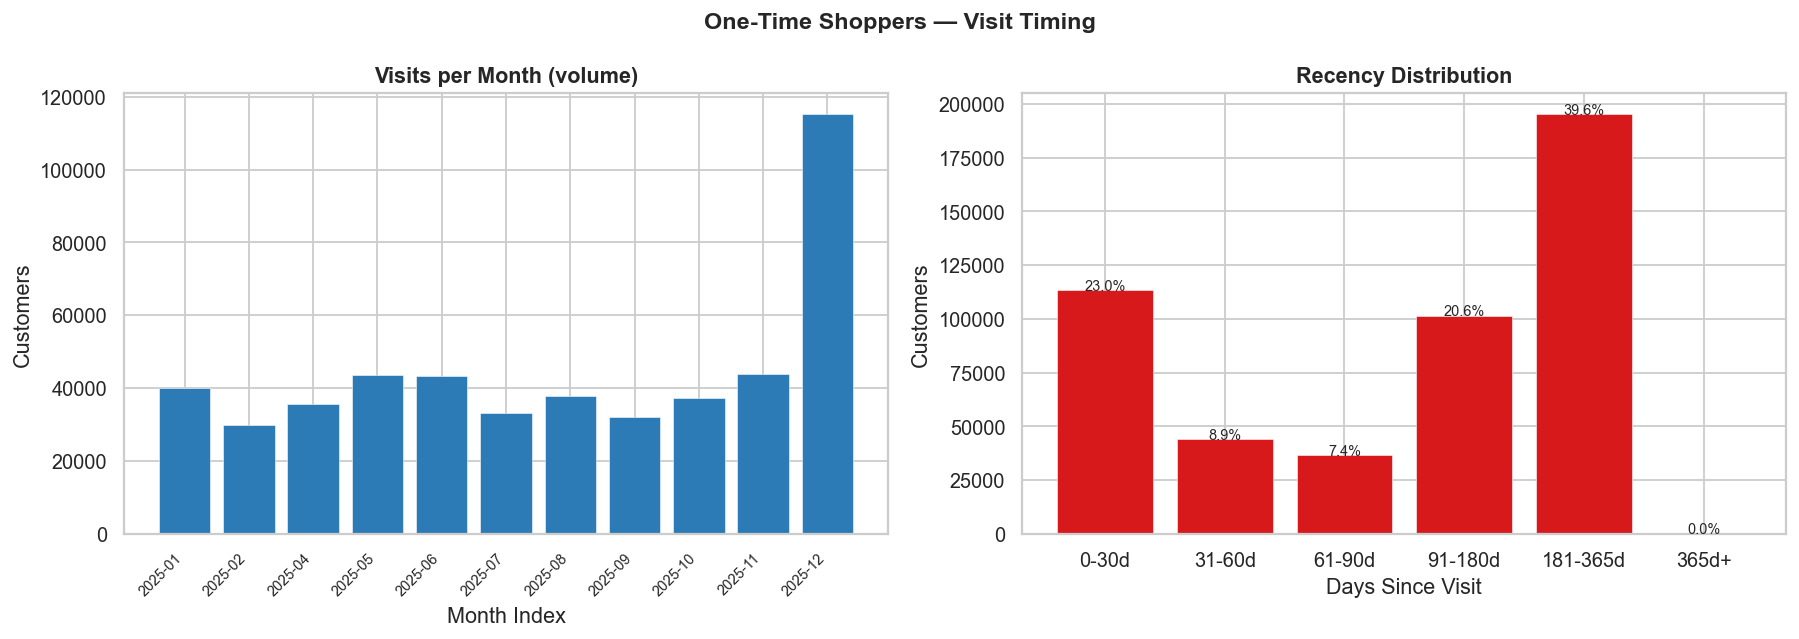

In [12]:
# ── 4.3 Visit timing — month distribution and recency ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('One-Time Shoppers — Visit Timing', fontweight='bold')

# Monthly visit volume
monthly_visits = ots['visit_year_month'].value_counts().sort_index()
ax1.bar(range(len(monthly_visits)), monthly_visits.values,
        color=PALETTE[0], edgecolor='white', linewidth=0.3)
ax1.set_title('Visits per Month (volume)')
ax1.set_xlabel('Month Index'); ax1.set_ylabel('Customers')
ax1.set_xticks(range(len(monthly_visits)))
ax1.set_xticklabels([str(m) for m in monthly_visits.index],
                    rotation=45, ha='right', fontsize=8)

# Recency distribution
ots['recency_bucket'] = pd.cut(
    ots['recency_days'],
    bins=[0, 30, 60, 90, 180, 365, 9999],
    labels=['0-30d','31-60d','61-90d','91-180d','181-365d','365d+']
)
rec_counts = ots['recency_bucket'].value_counts().sort_index()
ax2.bar(rec_counts.index, rec_counts.values,
        color=PALETTE[1], edgecolor='white', linewidth=0.3)
ax2.set_title('Recency Distribution')
ax2.set_xlabel('Days Since Visit'); ax2.set_ylabel('Customers')
for i, (cat, val) in enumerate(rec_counts.items()):
    ax2.text(i, val + 5, f'{val/len(ots)*100:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('OTS_03_timing.png', dpi=150, bbox_inches='tight')
plt.show()


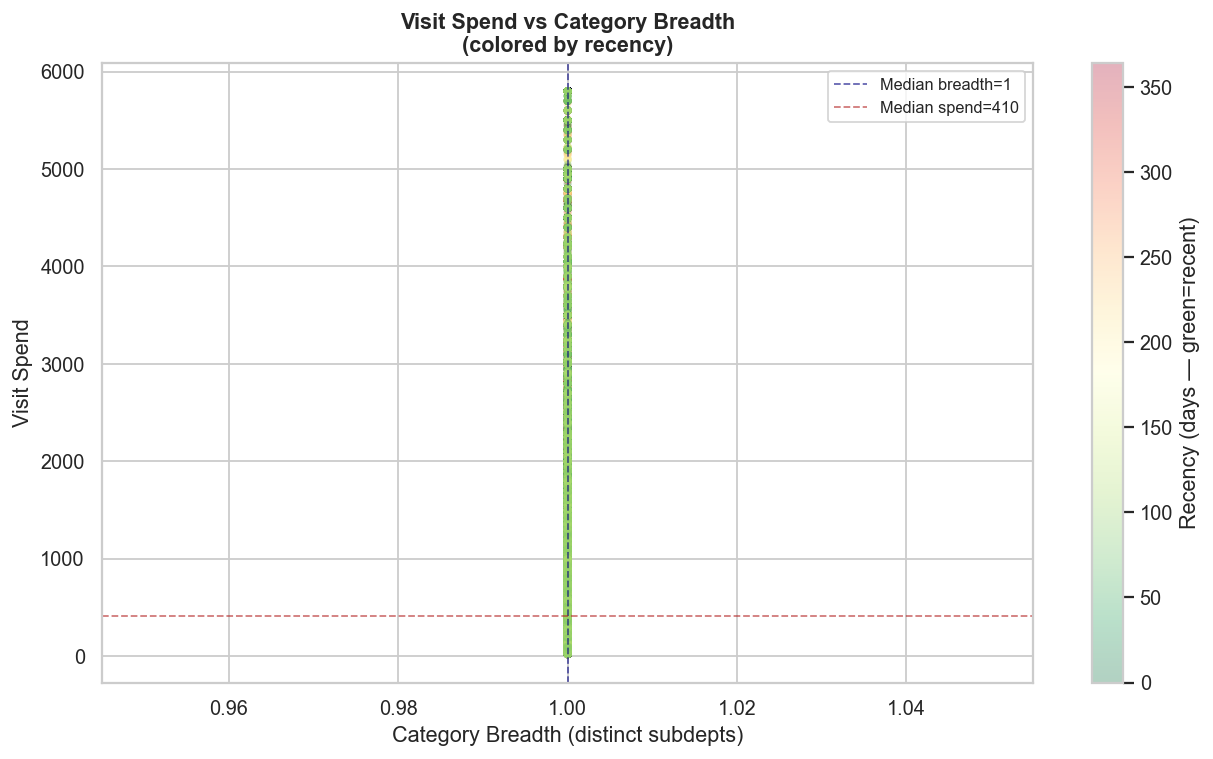

In [13]:
# ── 4.4 Spend vs category breadth scatter ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ots['category_breadth'],
    ots['visit_spend'].clip(upper=ots['visit_spend'].quantile(0.99)),
    c=ots['recency_days'],
    cmap='RdYlGn_r', alpha=0.3, s=12
)
plt.colorbar(sc, label='Recency (days — green=recent)')
ax.set_title('Visit Spend vs Category Breadth\n(colored by recency)',
             fontweight='bold')
ax.set_xlabel('Category Breadth (distinct subdepts)')
ax.set_ylabel('Visit Spend')
ax.axvline(ots['category_breadth'].median(), color='navy',
           linestyle='--', lw=1, alpha=0.6,
           label=f'Median breadth={ots["category_breadth"].median():.0f}')
ax.axhline(ots['visit_spend'].median(), color='firebrick',
           linestyle='--', lw=1, alpha=0.6,
           label=f'Median spend={ots["visit_spend"].median():.0f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('OTS_04_spend_breadth.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Behavioral Clustering

Cluster one-time shoppers purely on **what happened during their single visit**.

Clustering features: visit spend, units, spend/unit, category breadth,
top category concentration, bulk flag, recency, visit month index.

> Recency and timing are included because a shopper who visited 2 weeks ago
> is fundamentally different from one who visited 11 months ago —
> the win-back window, urgency, and likely product needs all differ.


In [14]:
# ── 5.1 Prepare feature matrix ────────────────────────────────────────────────
cluster_input = ots[['customer_id'] + OTS_FEATURES].dropna(subset=OTS_FEATURES).copy()

for col in OTS_FEATURES:
    lo, hi = cluster_input[col].quantile([0.01, 0.99])
    cluster_input[col] = cluster_input[col].clip(lo, hi)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_input[OTS_FEATURES])

print(f"Customers for clustering : {len(cluster_input):,}")
print(f"Features                 : {OTS_FEATURES}")


Customers for clustering : 492,394
Features                 : ['visit_spend', 'visit_units', 'spend_per_unit', 'category_breadth', 'top_category_share', 'is_bulk_visit', 'recency_days', 'visit_month_index']


  k=2  inertia=2,058,287  silhouette=0.4933
  k=3  inertia=1,406,041  silhouette=0.5332
  k=4  inertia=804,533  silhouette=0.4991
  k=5  inertia=671,644  silhouette=0.5075
  k=6  inertia=562,664  silhouette=0.4423
  k=7  inertia=460,466  silhouette=0.4620
  k=8  inertia=391,207  silhouette=0.4695


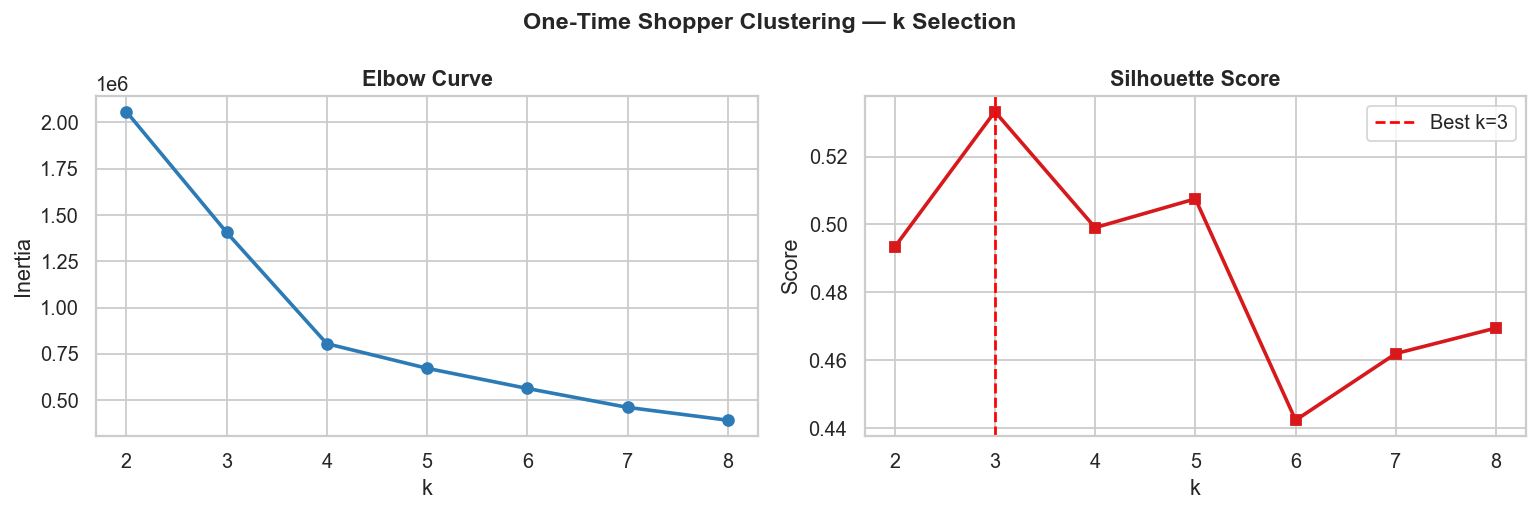


Best k = 3


In [15]:
# ── 5.2 Optimal k — elbow + silhouette ───────────────────────────────────────
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl,
                           sample_size=min(5000, len(X_scaled)),
                           random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

best_k = list(K_RANGE)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_RANGE), inertias,    'o-', color=PALETTE[0], lw=2)
ax1.set_title('Elbow Curve'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')

ax2.plot(list(K_RANGE), silhouettes, 's-', color=PALETTE[1], lw=2)
ax2.axvline(best_k, color='red', linestyle='--', lw=1.5, label=f'Best k={best_k}')
ax2.set_title('Silhouette Score'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
ax2.legend()

plt.suptitle('One-Time Shopper Clustering — k Selection', fontweight='bold')
plt.tight_layout()
plt.savefig('OTS_05_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest k = {best_k}")


In [17]:
# ── 5.3 Fit final model ───────────────────────────────────────────────────────
K_FINAL = best_k 

km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)

# 1. Assign clusters to the input dataframe
cluster_input['cluster'] = km_final.fit_predict(X_scaled)

# 2. Drop 'cluster' from 'ots' if it already exists to avoid suffixes like _x or _y
if 'cluster' in ots.columns:
    ots = ots.drop(columns=['cluster'])

# 3. Merge
ots = ots.merge(cluster_input[['customer_id', 'cluster']], on='customer_id', how='left')

# 4. Print distribution
dist = ots['cluster'].value_counts().sort_index()
print(f"K_FINAL = {K_FINAL}")
for c, n in dist.items():
    print(f"   Cluster {c}: {n:,} ({n/len(ots)*100:.1f}%)")

K_FINAL = 3
   Cluster 0: 85,335 (17.3%)
   Cluster 1: 395,311 (80.3%)
   Cluster 2: 11,748 (2.4%)


In [18]:
# ── 5.4 Cluster centroids ─────────────────────────────────────────────────────
centroids = (
    ots.dropna(subset=['cluster'])
       .groupby('cluster')[OTS_FEATURES]
       .median()
)
centroids['n']   = ots['cluster'].value_counts().sort_index()
centroids['pct'] = (centroids['n'] / len(ots) * 100).round(1)

print("=== Cluster Centroids (median) ===")
centroids.T.round(3)


=== Cluster Centroids (median) ===


cluster,0,1,2
visit_spend,632.000,399.000,4899.000
visit_units,2.000,1.000,1.000
spend_per_unit,299.000,399.000,4699.000
category_breadth,1.000,1.000,1.000
top_category_share,1.000,1.000,1.000
is_bulk_visit,1.000,0.000,0.000
recency_days,136.000,136.000,162.000
visit_month_index,4.000,4.000,5.000
n,85335.000,395311.000,11748.000
pct,17.300,80.300,2.400


In [19]:
# ── 5.5 Auto-name segments from centroid profile ──────────────────────────────
SEGMENT_NAMES = {}

med_spend   = centroids['visit_spend'].median()
med_units   = centroids['visit_units'].median()
med_breadth = centroids['category_breadth'].median()
med_conc    = centroids['top_category_share'].median()
med_recency = centroids['recency_days'].median()
med_spu     = centroids['spend_per_unit'].median()

for c in sorted(ots['cluster'].dropna().unique()):
    c = int(c)
    spend   = centroids.loc[c, 'visit_spend']
    units   = centroids.loc[c, 'visit_units']
    breadth = centroids.loc[c, 'category_breadth']
    conc    = centroids.loc[c, 'top_category_share']
    recency = centroids.loc[c, 'recency_days']
    spu     = centroids.loc[c, 'spend_per_unit']
    bulk    = centroids.loc[c, 'is_bulk_visit']

    if recency > med_recency * 1.5:
        name = 'Distant Lapsed'
    elif bulk >= 0.5 and units > med_units * 1.5:
        name = 'One-Trip Stockpilers'
    elif spend > med_spend * 1.4 and breadth > med_breadth:
        name = 'High-Value Explorers'
    elif spend > med_spend * 1.3 and conc > med_conc * 1.2:
        name = 'Focused High-Spenders'
    elif breadth > med_breadth * 1.3 and spend <= med_spend:
        name = 'Curious Browsers'
    elif recency <= med_recency * 0.5:
        name = 'Recent Light Buyers'
    else:
        name = 'Moderate Single-Visit'

    SEGMENT_NAMES[c] = name
    print(f"Cluster {c} ({centroids.loc[c,'pct']:.1f}%) → '{name}'")

ots['segment'] = ots['cluster'].map(SEGMENT_NAMES)


Cluster 0 (17.3%) → 'One-Trip Stockpilers'
Cluster 1 (80.3%) → 'Moderate Single-Visit'
Cluster 2 (2.4%) → 'Moderate Single-Visit'


---
## 6. Segment Cards

In [20]:
# ── 6.1 Overall baseline ─────────────────────────────────────────────────────
CARD_METRICS = [
    'visit_spend', 'visit_units', 'spend_per_unit',
    'category_breadth', 'top_category_share',
    'recency_days', 'visit_month_index',
]
baseline = ots[CARD_METRICS].median()

print("=== One-Time Shopper Baseline (median) ===")
baseline.round(2)


=== One-Time Shopper Baseline (median) ===


visit_spend          410.000
visit_units            1.000
spend_per_unit       359.200
category_breadth       1.000
top_category_share     1.000
recency_days         136.000
visit_month_index      4.000
dtype: float64

In [21]:
# ── 6.2 Print segment cards ───────────────────────────────────────────────────
sow_cols = [c for c in ots.columns if c.startswith('sow__')]

for seg_name in SEGMENT_NAMES.values():
    grp = ots[ots['segment'] == seg_name]
    if grp.empty:
        continue

    print('=' * 65)
    print(f'  SEGMENT: {seg_name.upper()}')
    print('=' * 65)
    n   = len(grp)
    pct = n / len(ots) * 100
    print(f"  {'Customers':30s}: {n:,} ({pct:.1f}% of one-time shoppers)")

    for col in CARD_METRICS:
        val      = grp[col].median()
        base_val = baseline[col]
        if base_val != 0:
            diff_pct  = (val - base_val) / abs(base_val) * 100
            direction = '▲' if diff_pct > 5 else ('▼' if diff_pct < -5 else '≈')
            print(f"  {col:30s}: {val:>10.2f}  {direction} {abs(diff_pct):.0f}% vs avg")
        else:
            print(f"  {col:30s}: {val:>10.2f}")

    # Bulk and journey stage
    bulk_rate = grp['is_bulk_visit'].mean() * 100
    top_stage = grp['journey_stage'].mode().iloc[0] if len(grp) else 'N/A'
    top_cat   = grp['top_category'].mode().iloc[0]  if len(grp) else 'N/A'
    print(f"  {'Bulk visit rate':30s}: {bulk_rate:.1f}%")
    print(f"  {'Top journey stage':30s}: {top_stage}")
    print(f"  {'Top category':30s}: {top_cat}")

    # Distinguishing features (top 3 deviations from baseline)
    grp_med  = grp[CARD_METRICS].median()
    base_abs = baseline.abs().clip(lower=1e-9)
    rel_dev  = (grp_med - baseline) / base_abs
    top_devs = rel_dev.abs().nlargest(3)
    print(f"  {'Top distinguishing traits':30s}:")
    for feat in top_devs.index:
        dev = rel_dev[feat]
        direction = 'much higher' if dev > 0 else 'much lower'
        print(f"    → {feat}: {direction} ({dev*100:+.0f}% vs avg)")
    print()


  SEGMENT: ONE-TRIP STOCKPILERS
  Customers                     : 85,335 (17.3% of one-time shoppers)
  visit_spend                   :     632.00  ▲ 54% vs avg
  visit_units                   :       2.00  ▲ 100% vs avg
  spend_per_unit                :     299.00  ▼ 17% vs avg
  category_breadth              :       1.00  ≈ 0% vs avg
  top_category_share            :       1.00  ≈ 0% vs avg
  recency_days                  :     136.00  ≈ 0% vs avg
  visit_month_index             :       4.00  ≈ 0% vs avg
  Bulk visit rate               : 100.0%
  Top journey stage             : Other
  Top category                  : toiletries
  Top distinguishing traits     :
    → visit_units: much higher (+100% vs avg)
    → visit_spend: much higher (+54% vs avg)
    → spend_per_unit: much lower (-17% vs avg)

  SEGMENT: MODERATE SINGLE-VISIT
  Customers                     : 407,059 (82.7% of one-time shoppers)
  visit_spend                   :     399.00  ≈ 3% vs avg
  visit_units              

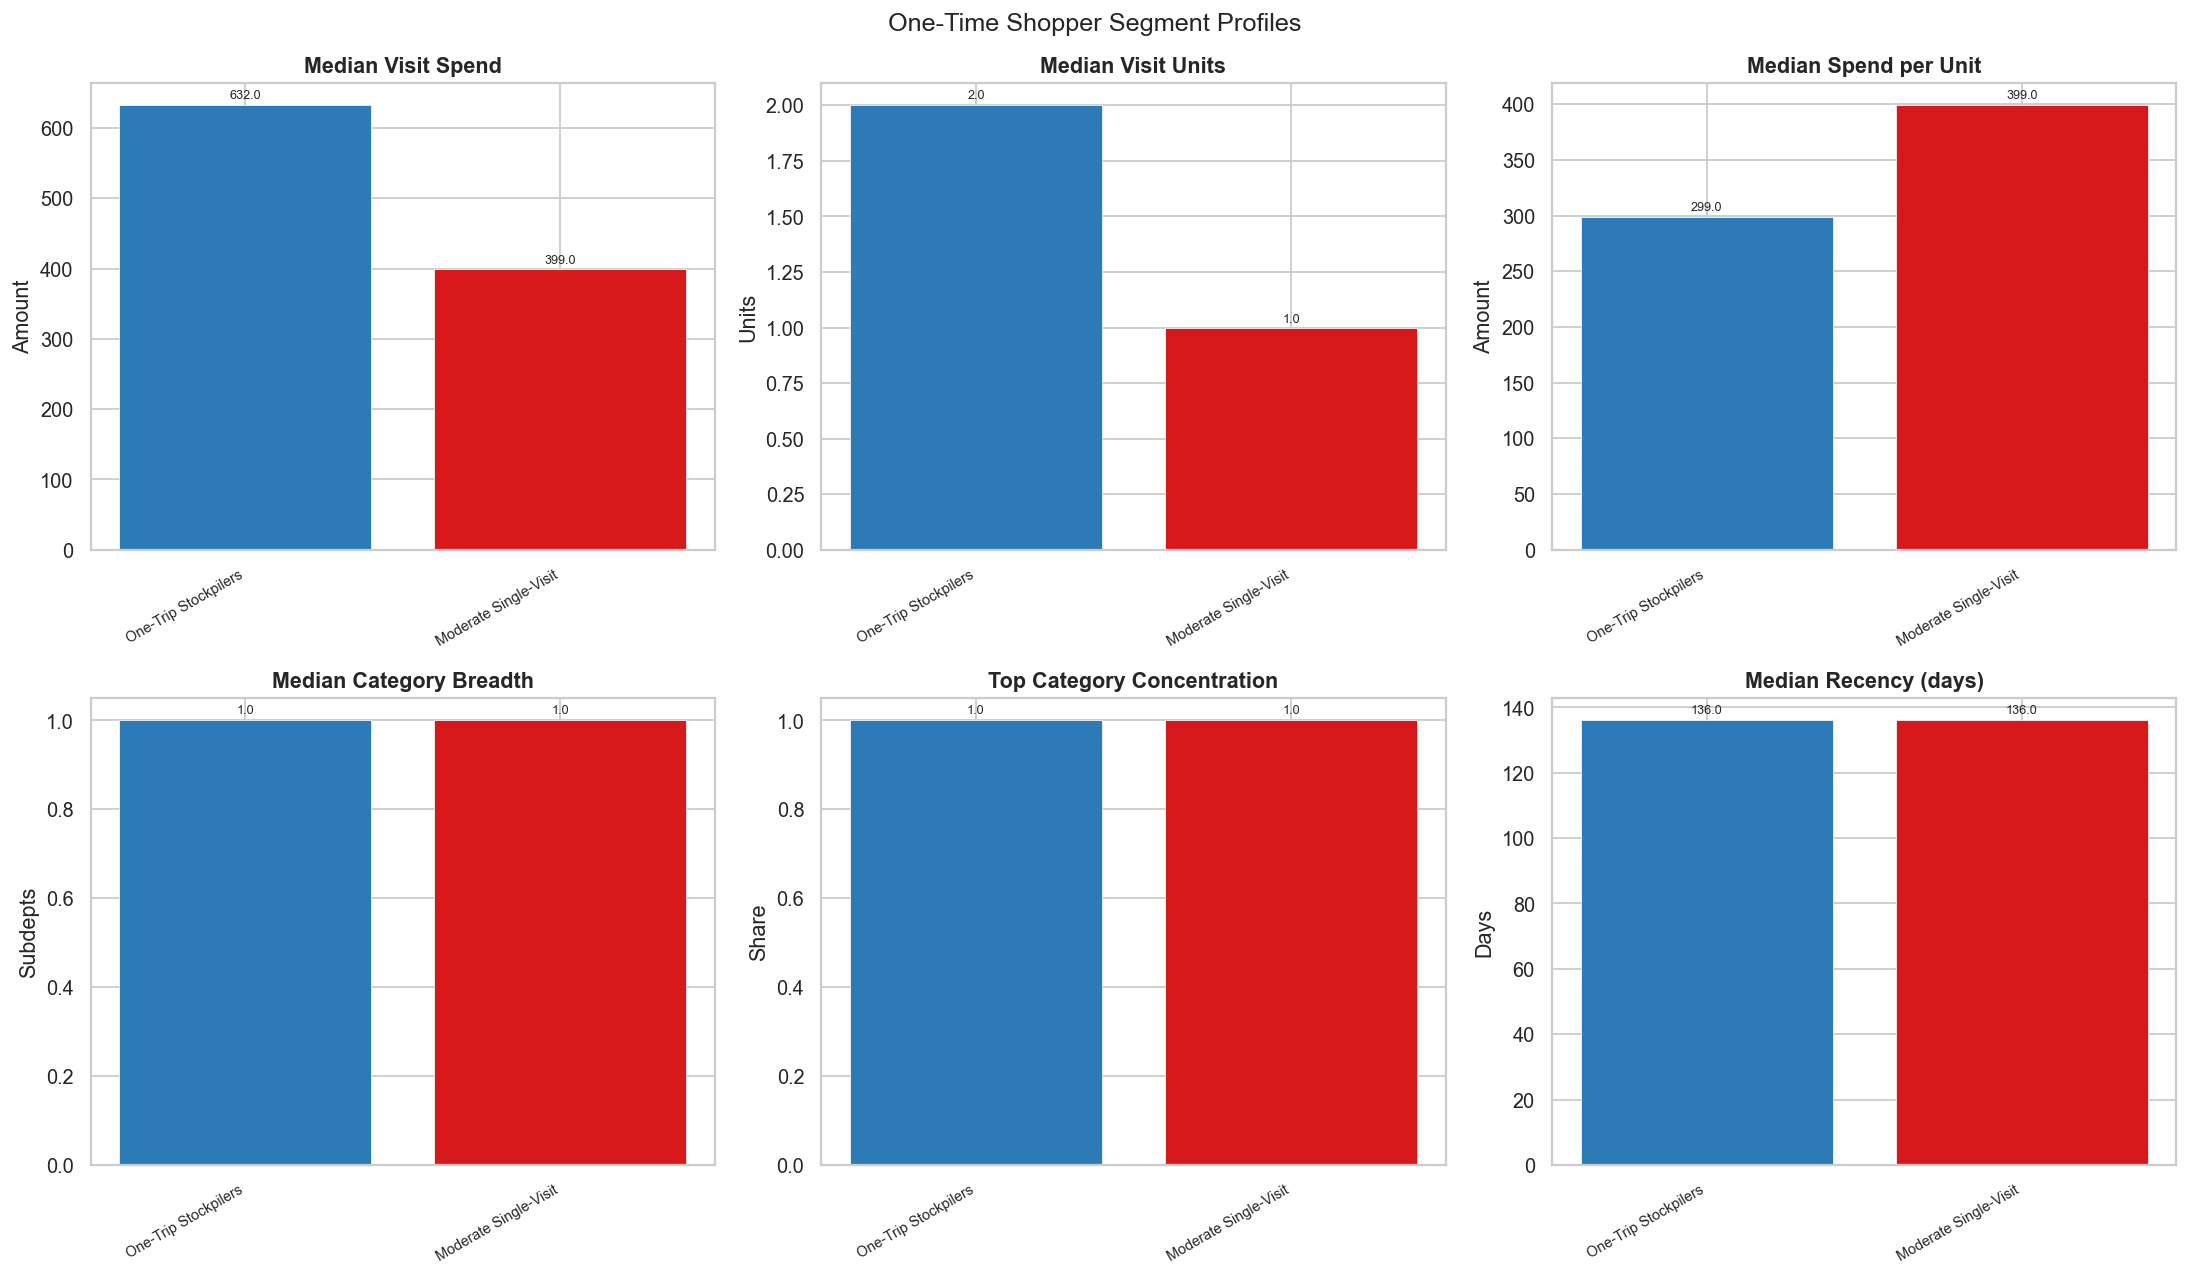

In [22]:
# ── 6.3 Segment comparison — bar charts ──────────────────────────────────────
seg_order = (
    ots.dropna(subset=['segment'])
       .groupby('segment')['visit_spend']
       .median().sort_values(ascending=False).index.tolist()
)

plot_metrics = [
    ('visit_spend',        'Median Visit Spend',       'Amount'),
    ('visit_units',        'Median Visit Units',        'Units'),
    ('spend_per_unit',     'Median Spend per Unit',     'Amount'),
    ('category_breadth',   'Median Category Breadth',   'Subdepts'),
    ('top_category_share', 'Top Category Concentration','Share'),
    ('recency_days',       'Median Recency (days)',      'Days'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('One-Time Shopper Segment Profiles', fontsize=14)

for ax, (col, title, ylabel) in zip(axes.flatten(), plot_metrics):
    vals   = ots.groupby('segment')[col].median().reindex(seg_order)
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(vals))]
    bars   = ax.bar(vals.index, vals.values, color=colors,
                    edgecolor='white', linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('OTS_06_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


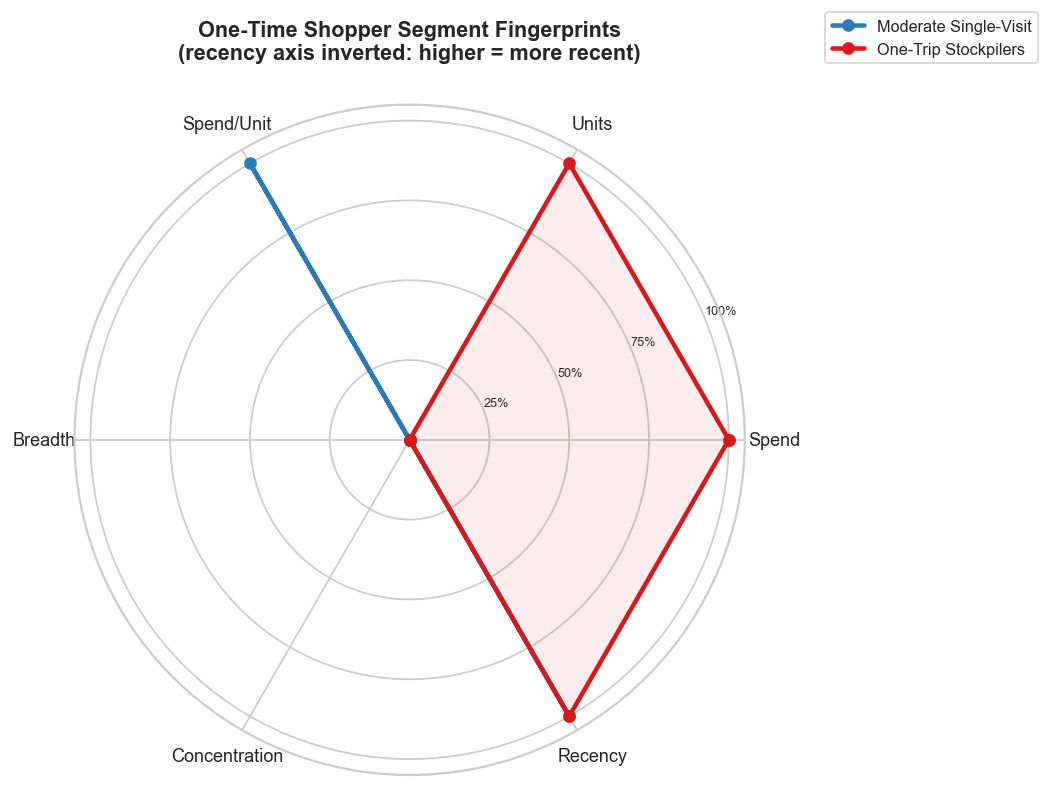

In [23]:
# ── 6.4 Radar chart ───────────────────────────────────────────────────────────
radar_feats  = ['visit_spend','visit_units','spend_per_unit',
                'category_breadth','top_category_share','recency_days']
radar_labels = ['Spend','Units','Spend/Unit','Breadth','Concentration','Recency']

seg_radar = ots.dropna(subset=['segment']).groupby('segment')[radar_feats].median()
seg_norm  = (seg_radar - seg_radar.min()) / (seg_radar.max() - seg_radar.min() + 1e-9)
# Invert recency so higher = better (more recent)
seg_norm['recency_days'] = 1 - seg_norm['recency_days']

N      = len(radar_feats)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for i, (seg, row) in enumerate(seg_norm.iterrows()):
    vals  = row.tolist() + [row.tolist()[0]]
    color = PALETTE[i % len(PALETTE)]
    ax.plot(angles, vals, 'o-', linewidth=2.5, color=color, label=seg)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=7)
ax.set_title('One-Time Shopper Segment Fingerprints\n(recency axis inverted: higher = more recent)',
             fontsize=12, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('OTS_07_radar.png', dpi=150, bbox_inches='tight')
plt.show()


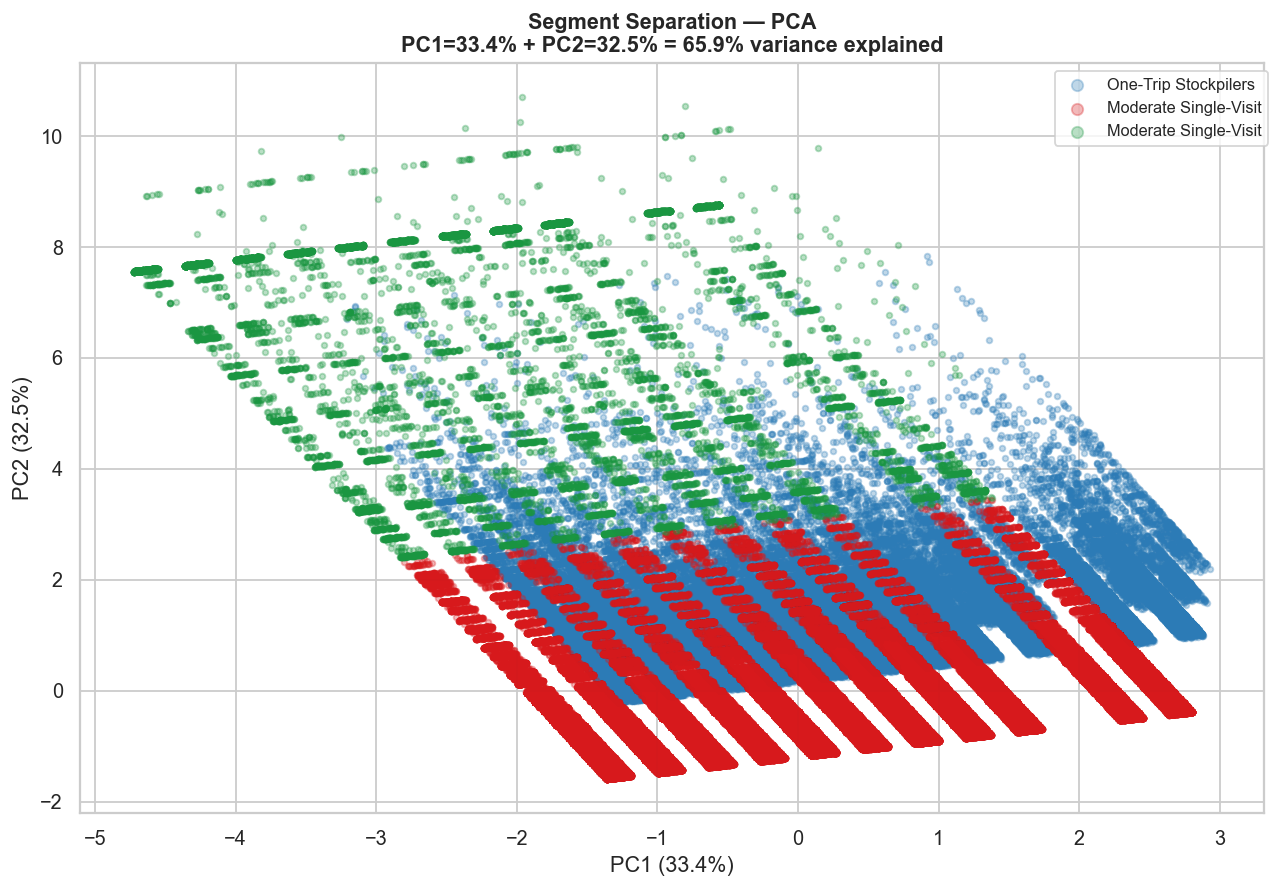

In [24]:
# ── 6.5 PCA scatter ───────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
Xp    = pca.fit_transform(X_scaled)
ve    = pca.explained_variance_ratio_

pca_df = cluster_input[['customer_id','cluster']].copy()
pca_df['pc1'] = Xp[:, 0]
pca_df['pc2'] = Xp[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
for c in sorted(pca_df['cluster'].unique()):
    mask  = pca_df['cluster'] == c
    label = SEGMENT_NAMES.get(int(c), f'Cluster {c}')
    ax.scatter(pca_df.loc[mask,'pc1'], pca_df.loc[mask,'pc2'],
               label=label, alpha=0.3, s=10,
               color=PALETTE[int(c) % len(PALETTE)])

ax.set_title(f'Segment Separation — PCA\n'
             f'PC1={ve[0]*100:.1f}% + PC2={ve[1]*100:.1f}% = '
             f'{sum(ve)*100:.1f}% variance explained', fontweight='bold')
ax.set_xlabel(f'PC1 ({ve[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({ve[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, bbox_to_anchor=(1.01,1))
plt.tight_layout()
plt.savefig('OTS_08_pca.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7. Win-Back Scoring — Conversion to Repeat Shopper

**Objective:** Rank one-time shoppers by their likelihood of making a second purchase.

**Method:** Logistic Regression trained on features that distinguish customers who
*did* return (now in the repeat shopper pool) from those who visited once and stopped.

**Label construction (proxy):**
- Label = 1 : customer appears in the **repeat shopper** profile (returned)
- Label = 0 : customer remains a one-time shopper

This is a retrospective exercise. In production this score runs monthly on the
current one-time shopper cohort.

**Win-back score** = predicted probability of conversion (0–1).
Higher score → prioritise for re-engagement campaign.


In [25]:
# ── 7.1 Build labelled dataset from Phase 1 full profile ─────────────────────
# All customers in the Phase 1 profile who share the same single-visit features.
# Label 1 = became a repeat shopper, Label 0 = stayed one-time.

# We use only features available at the time of the single visit (no leakage).
WINBACK_FEATURES = [
    'visit_spend',
    'visit_units',
    'spend_per_unit',
    'category_breadth',
    'top_category_share',
    'is_bulk_visit',
    'recency_days',
    'visit_month_index',
]

# Current one-time shoppers — label 0
ots_labelled = ots[['customer_id'] + WINBACK_FEATURES].copy()
ots_labelled['label'] = 0

# Repeat shoppers — reconstruct their "first visit" features from raw data
repeat_ids = set(
    profile[profile['shopper_type'] == 'Repeat']['customer_id'].values
)
seq_repeat = raw[raw['customer_id'].isin(repeat_ids)].copy()

# First visit date per repeat customer
first_visit = (
    seq_repeat.groupby('customer_id')['date']
              .min()
              .reset_index(name='first_date')
)

# Rows from their first shopping day only
seq_repeat = seq_repeat.merge(first_visit, on='customer_id')
seq_first  = seq_repeat[seq_repeat['date'] == seq_repeat['first_date']].copy()

# Compute same features on their first visit
first_stats = (
    seq_first.groupby('customer_id')
             .agg(
                 visit_spend      = ('total_sales',           'sum'),
                 visit_units      = ('total_units',           'sum'),
                 category_breadth = ('subdepartment_cleaned', 'nunique'),
                 visit_date       = ('date',                  'first'),
             )
             .reset_index()
)
first_stats['spend_per_unit'] = (
    first_stats['visit_spend'] / first_stats['visit_units'].clip(lower=1)
)
first_stats['recency_days'] = (SNAPSHOT_DATE - first_stats['visit_date']).dt.days

snap_ym = SNAPSHOT_DATE.year * 12 + SNAPSHOT_DATE.month
first_stats['visit_year_month'] = first_stats['visit_date'].dt.to_period('M')
first_stats['visit_month_index'] = (
    snap_ym
    - first_stats['visit_date'].dt.year * 12
    - first_stats['visit_date'].dt.month
)

# Top category share for repeat shoppers first visit
first_subdept = (
    seq_first.groupby(['customer_id','subdepartment_cleaned'])['total_units']
             .sum().reset_index(name='subdept_units')
)
first_total = (
    seq_first.groupby('customer_id')['total_units']
             .sum().reset_index(name='tot_units')
)
first_subdept = first_subdept.merge(first_total, on='customer_id')
first_subdept['share'] = first_subdept['subdept_units'] / first_subdept['tot_units'].clip(lower=1)
first_top_share = (
    first_subdept.groupby('customer_id')['share']
                 .max()
                 .rename('top_category_share')
                 .reset_index()
)
first_stats = first_stats.merge(first_top_share, on='customer_id', how='left')

# Bulk flag using same threshold as OTS
first_stats['is_bulk_visit'] = (first_stats['visit_units'] >= bulk_threshold).astype(int)
first_stats['label'] = 1

repeat_labelled = first_stats[['customer_id'] + WINBACK_FEATURES + ['label']].copy()

# Combine and prepare
combined = pd.concat([ots_labelled, repeat_labelled], ignore_index=True)
combined = combined.dropna(subset=WINBACK_FEATURES)

# Clip to same percentile bounds used for clustering
for col in WINBACK_FEATURES:
    lo, hi = combined[col].quantile([0.01, 0.99])
    combined[col] = combined[col].clip(lo, hi)

print(f"Labelled dataset: {len(combined):,} total")
print(f"  Label 1 (became repeat): {combined['label'].sum():,}")
print(f"  Label 0 (stayed OTS)   : {(combined['label']==0).sum():,}")
print(f"  Conversion rate        : {combined['label'].mean()*100:.1f}%")


Labelled dataset: 1,121,614 total
  Label 1 (became repeat): 629,220
  Label 0 (stayed OTS)   : 492,394
  Conversion rate        : 56.1%


In [26]:
# ── 7.2 Train win-back model ──────────────────────────────────────────────────
X_wb = combined[WINBACK_FEATURES].values
y_wb = combined['label'].values

# Scale using same approach as clustering
wb_scaler = StandardScaler()
X_wb_sc   = wb_scaler.fit_transform(X_wb)

# Logistic Regression — interpretable, fast, well-calibrated for scoring
wb_model = LogisticRegression(
    class_weight='balanced',   # handles imbalanced label distribution
    max_iter=1000,
    random_state=RANDOM_STATE
)
wb_model.fit(X_wb_sc, y_wb)

# Cross-validated ROC-AUC
cv_scores = cross_val_score(wb_model, X_wb_sc, y_wb, cv=5, scoring='roc_auc')
print(f"Win-back model — 5-fold ROC-AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Feature importance (log-odds coefficients)
coef_df = (
    pd.Series(wb_model.coef_[0], index=WINBACK_FEATURES)
      .sort_values(key=abs, ascending=False)
)
print("\nFeature importance (log-odds, absolute):")
for feat, coef in coef_df.items():
    direction = '↑ return' if coef > 0 else '↓ return'
    print(f"  {feat:30s}: {coef:+.3f}  ({direction})")


Win-back model — 5-fold ROC-AUC: 0.851 ± 0.142

Feature importance (log-odds, absolute):
  top_category_share            : -3.920  (↓ return)
  category_breadth              : +2.557  (↑ return)
  recency_days                  : +1.225  (↑ return)
  visit_units                   : +0.874  (↑ return)
  is_bulk_visit                 : +0.341  (↑ return)
  visit_month_index             : -0.275  (↓ return)
  visit_spend                   : +0.273  (↑ return)
  spend_per_unit                : -0.121  (↓ return)


In [27]:
# ── 7.3 Score all current one-time shoppers ───────────────────────────────────
ots_features = ots[WINBACK_FEATURES].copy().fillna(0)
for col in WINBACK_FEATURES:
    lo, hi = combined[col].quantile([0.01, 0.99])
    ots_features[col] = ots_features[col].clip(lo, hi)

ots_scaled = wb_scaler.transform(ots_features[WINBACK_FEATURES])
ots['winback_score'] = wb_model.predict_proba(ots_scaled)[:, 1]

# Score tiers
score_bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
score_labels = ['Very Low','Low','Moderate','High','Very High']
ots['winback_tier'] = pd.cut(
    ots['winback_score'], bins=score_bins, labels=score_labels, include_lowest=True
)

print("Win-back score distribution:")
tier_counts = ots['winback_tier'].value_counts().sort_index(ascending=False)
for tier, n in tier_counts.items():
    print(f"  {tier:12s}: {n:,} ({n/len(ots)*100:.1f}%)")

print(f"\nMedian win-back score : {ots['winback_score'].median():.3f}")
print(f"Top 10% threshold     : {ots['winback_score'].quantile(0.90):.3f}")


Win-back score distribution:
  Very High   : 8,886 (1.8%)
  High        : 40,023 (8.1%)
  Moderate    : 85,362 (17.3%)
  Low         : 160,746 (32.6%)
  Very Low    : 197,377 (40.1%)

Median win-back score : 0.250
Top 10% threshold     : 0.599


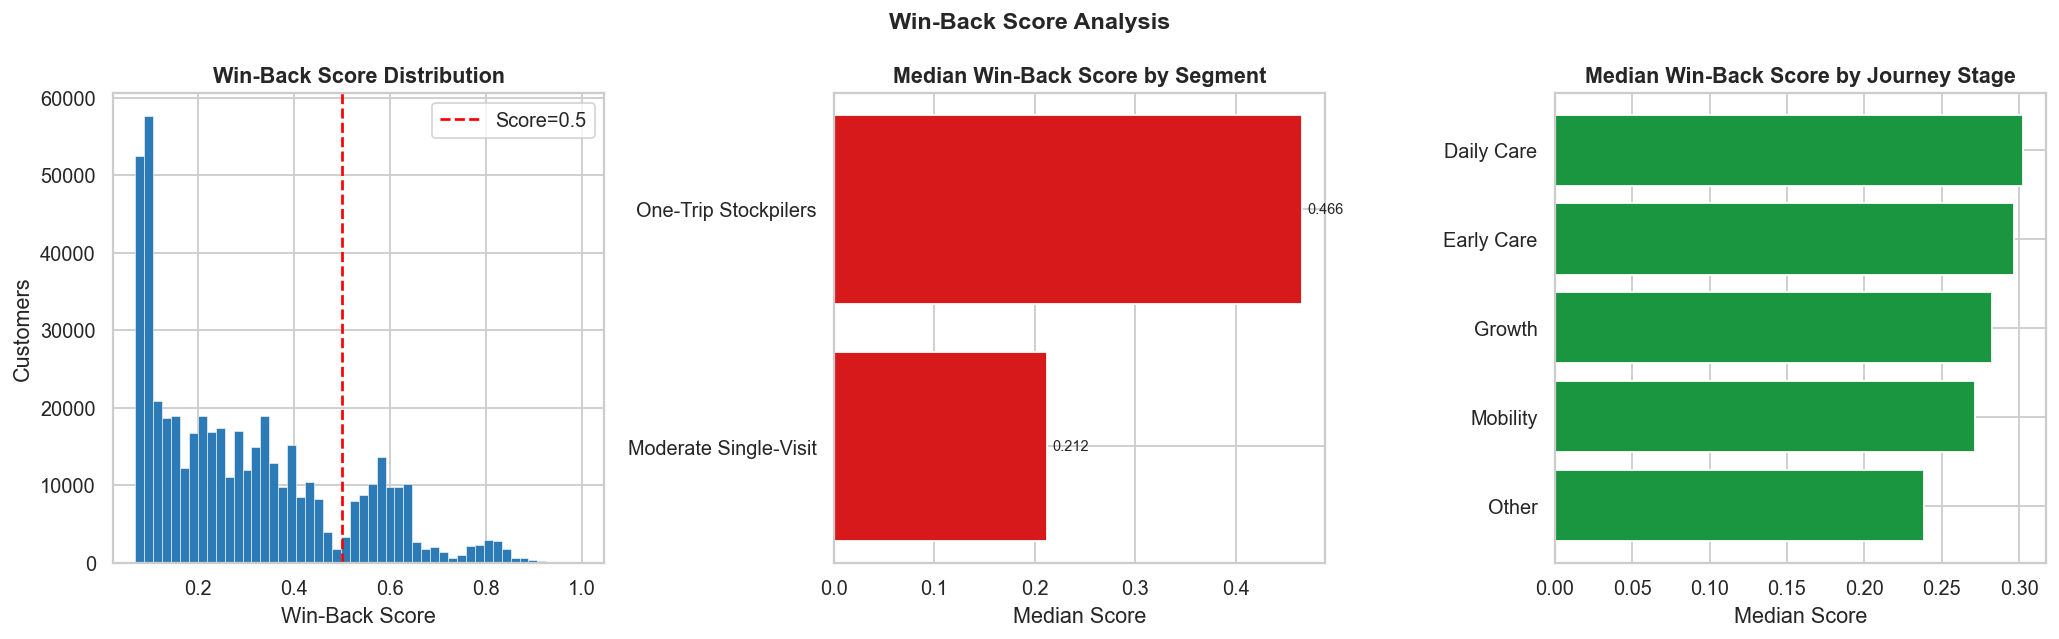

In [28]:
# ── 7.4 Win-back score visualisations ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Win-Back Score Analysis', fontweight='bold')

# Score distribution
axes[0].hist(ots['winback_score'], bins=50, color=PALETTE[0],
             edgecolor='white', linewidth=0.3)
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='Score=0.5')
axes[0].set_title('Win-Back Score Distribution')
axes[0].set_xlabel('Win-Back Score'); axes[0].set_ylabel('Customers')
axes[0].legend()

# Score by segment
seg_scores = ots.groupby('segment')['winback_score'].median().sort_values(ascending=False)
axes[1].barh(seg_scores.index, seg_scores.values,
             color=PALETTE[1], edgecolor='white')
axes[1].set_title('Median Win-Back Score by Segment')
axes[1].set_xlabel('Median Score'); axes[1].invert_yaxis()
for i, (seg, val) in enumerate(seg_scores.items()):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

# Score by journey stage
stage_scores = ots.groupby('journey_stage')['winback_score'].median().sort_values(ascending=False)
axes[2].barh(stage_scores.index, stage_scores.values,
             color=PALETTE[2], edgecolor='white')
axes[2].set_title('Median Win-Back Score by Journey Stage')
axes[2].set_xlabel('Median Score'); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('OTS_09_winback_scores.png', dpi=150, bbox_inches='tight')
plt.show()


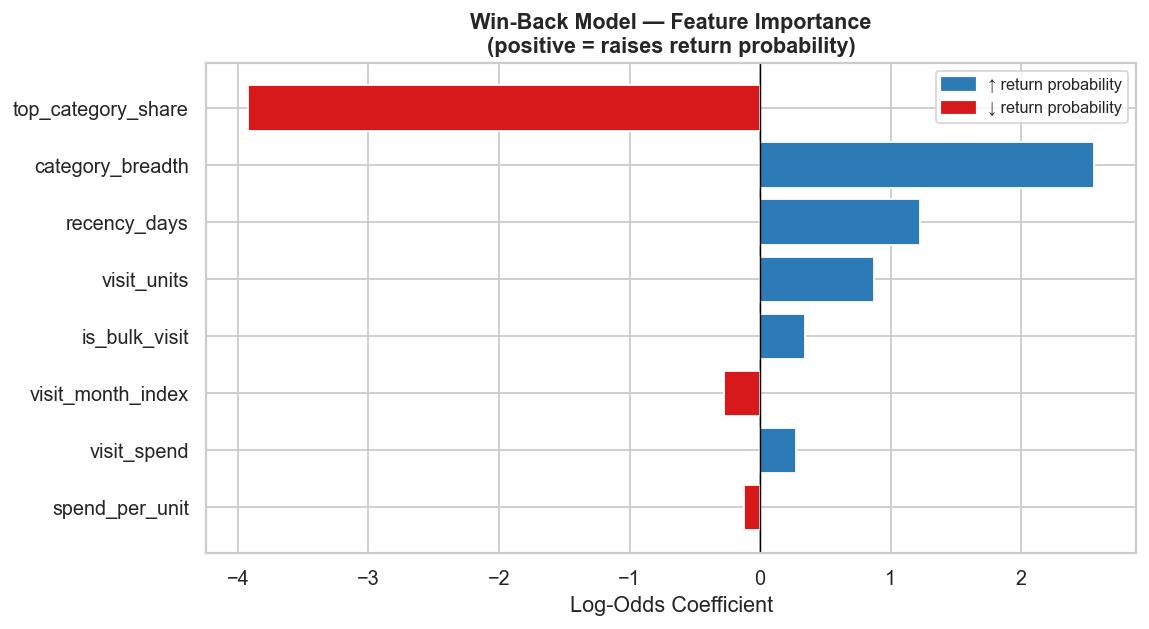

In [29]:
# ── 7.5 Feature importance chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[0] if c > 0 else PALETTE[1] for c in coef_df.values]
ax.barh(coef_df.index, coef_df.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Win-Back Model — Feature Importance\n(positive = raises return probability)',
             fontweight='bold')
ax.set_xlabel('Log-Odds Coefficient')
ax.invert_yaxis()
patches = [mpatches.Patch(color=PALETTE[0], label='↑ return probability'),
           mpatches.Patch(color=PALETTE[1], label='↓ return probability')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('OTS_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# ── 7.6 Top win-back targets ──────────────────────────────────────────────────
top_targets = (
    ots[ots['winback_tier'].isin(['High','Very High'])]
       [['customer_id','segment','journey_stage','visit_spend',
         'visit_units','category_breadth','recency_days',
         'top_category','winback_score','winback_tier']]
       .sort_values('winback_score', ascending=False)
       .reset_index(drop=True)
)

print(f"High / Very High win-back targets : {len(top_targets):,}")
print(f"  Median spend    : {top_targets['visit_spend'].median():.0f}")
print(f"  Median recency  : {top_targets['recency_days'].median():.0f} days")
print()
print("=== Top 20 Win-Back Targets ===")
top_targets.head(20).to_string(index=False)


High / Very High win-back targets : 48,909
  Median spend    : 548
  Median recency  : 346 days

=== Top 20 Win-Back Targets ===


' customer_id              segment journey_stage  visit_spend  visit_units  category_breadth  recency_days               top_category  winback_score winback_tier\n      845748 One-Trip Stockpilers    Daily Care    10830.000           78                 1           347                 toiletries          1.000    Very High\n      920101 One-Trip Stockpilers         Other     8900.000           20                 1           352         disposable diapers          1.000    Very High\n     1056143 One-Trip Stockpilers    Daily Care    13920.000          100                 1           212                 toiletries          0.999    Very High\n       70326 One-Trip Stockpilers         Other     8616.000           24                 1           274                 baby c + o          0.999    Very High\n      899327 One-Trip Stockpilers    Daily Care    15860.000           15                 1           351                 toiletries          0.999    Very High\n      939000 One-Trip Stock

---
## 8. Strategic Recommendations

In [31]:
recommendations = [
    {
        "n": 1,
        "title"  : "Immediate Re-engagement — High Win-Back Score + Recent",
        "segment": "Any segment with winback_tier = 'High' or 'Very High' AND recency_days < 60",
        "action" : "These customers visited recently and look behaviorally similar to repeat shoppers. "
                   "A single well-timed personalised push (email or app notification) within 30 days "
                   "of their visit has the highest conversion probability. Message: "
                   "'Welcome back — here's what's new in [their top category].'",
        "metric" : "Second visit rate within 60 days of campaign send",
    },
    {
        "n": 2,
        "title"  : "Category Completion — One-Trip Stockpilers",
        "segment": "One-Trip Stockpilers (high units, bulk flag)",
        "action" : "These customers made a large, intentional purchase. They likely have a specific "
                   "need they came to solve. The high basket volume suggests genuine engagement, "
                   "not a trial. Target them with adjacent category suggestions: "
                   "if they bought heavily in Newborn Essentials, next likely need is Nursing & Feeding. "
                   "Timing: 3-4 weeks after the visit (before they seek alternatives elsewhere).",
        "metric" : "Second visit rate; second visit category match to recommendation",
    },
    {
        "n": 3,
        "title"  : "Premium Upsell — Focused High-Spenders",
        "segment": "Focused High-Spenders (high spend, concentrated category)",
        "action" : "These shoppers spent a lot in one category on a single visit — they have "
                   "both the intent and the spending capacity. They're likely category-loyal. "
                   "Target with premium or subscription offers within their anchor category. "
                   "Avoid cross-category messaging which may feel irrelevant.",
        "metric" : "Second visit spend; subscription attach rate within anchor category",
    },
    {
        "n": 4,
        "title"  : "Curiosity Conversion — Curious Browsers",
        "segment": "Curious Browsers (high breadth, lower spend)",
        "action" : "These shoppers explored multiple categories on a single visit — "
                   "a strong signal of genuine interest across the baby product range. "
                   "They just haven't committed to a purchase routine yet. "
                   "A 'category guide' or curated bundle email (e.g., 'Complete Newborn Starter Kit') "
                   "may anchor them to a core category and trigger a second, higher-value visit.",
        "metric" : "Second visit rate; avg spend per visit on return",
    },
    {
        "n": 5,
        "title"  : "Lapsed Recovery — Distant Lapsed (180d+)",
        "segment": "Distant Lapsed (high recency_days)",
        "action" : "These shoppers visited more than 6 months ago and never returned. "
                   "The win-back window is long but not closed — baby needs evolve "
                   "with child age, so a message anchored to the next life stage "
                   "('Your baby is now around X months old — here\'s what parents are buying') "
                   "can re-establish relevance. Prioritise only those with winback_score > 0.4 "
                   "to avoid wasting campaign budget on truly disengaged shoppers.",
        "metric" : "Re-activation rate (any purchase within 90 days); cost per reactivation",
    },
]

for rec in recommendations:
    print(f"{'='*65}")
    print(f"  REC {rec['n']}: {rec['title'].upper()}")
    print(f"{'='*65}")
    print(f"  Target  : {rec['segment']}")
    print(f"  Action  : {rec['action']}")
    print(f"  Metric  : {rec['metric']}")
    print()


  REC 1: IMMEDIATE RE-ENGAGEMENT — HIGH WIN-BACK SCORE + RECENT
  Target  : Any segment with winback_tier = 'High' or 'Very High' AND recency_days < 60
  Action  : These customers visited recently and look behaviorally similar to repeat shoppers. A single well-timed personalised push (email or app notification) within 30 days of their visit has the highest conversion probability. Message: 'Welcome back — here's what's new in [their top category].'
  Metric  : Second visit rate within 60 days of campaign send

  REC 2: CATEGORY COMPLETION — ONE-TRIP STOCKPILERS
  Target  : One-Trip Stockpilers (high units, bulk flag)
  Action  : These customers made a large, intentional purchase. They likely have a specific need they came to solve. The high basket volume suggests genuine engagement, not a trial. Target them with adjacent category suggestions: if they bought heavily in Newborn Essentials, next likely need is Nursing & Feeding. Timing: 3-4 weeks after the visit (before they seek alternati

---
## 9. Output Files

In [32]:
# ── 9.1 Full one-time shopper profile ────────────────────────────────────────
OUT_COLS = [
    'customer_id',
    # Visit features
    'visit_date','visit_year_month','visit_spend','visit_units',
    'spend_per_unit','category_breadth','top_category_share',
    'is_bulk_visit','recency_days','visit_month_index',
    'recency_bucket',
    # Category
    'top_category','journey_stage',
    # Cluster output
    'cluster','segment',
    # Win-back
    'winback_score','winback_tier',
]
OUT_COLS = [c for c in OUT_COLS if c in ots.columns]

ots[OUT_COLS].to_parquet('one_time_shopper_profiles.parquet', index=False)
ots[OUT_COLS].to_csv('one_time_shopper_profiles.csv', index=False)
print(f"Saved: one_time_shopper_profiles.parquet")
print(f"  {len(ots):,} shoppers × {len(OUT_COLS)} columns")


Saved: one_time_shopper_profiles.parquet
  492,394 shoppers × 18 columns


In [33]:
# ── 9.2 Win-back targeting list (High + Very High tier only) ──────────────────
top_targets[['customer_id','segment','journey_stage',
             'visit_spend','recency_days','top_category',
             'winback_score','winback_tier']].to_csv(
    'winback_targets.csv', index=False
)
print(f"Saved: winback_targets.csv")
print(f"  {len(top_targets):,} high-priority win-back targets")


Saved: winback_targets.csv
  48,909 high-priority win-back targets


In [34]:
# ── 9.3 Segment summary card ─────────────────────────────────────────────────
seg_card = (
    ots.dropna(subset=['segment'])
       .groupby('segment')
       .agg(
           n_customers         = ('customer_id',       'count'),
           median_spend        = ('visit_spend',        'median'),
           median_units        = ('visit_units',        'median'),
           median_breadth      = ('category_breadth',   'median'),
           bulk_rate           = ('is_bulk_visit',      'mean'),
           median_recency      = ('recency_days',       'median'),
           median_winback_score= ('winback_score',      'median'),
       )
       .sort_values('median_winback_score', ascending=False)
)
seg_card['pct_of_ots'] = (
    seg_card['n_customers'] / len(ots) * 100
).round(1).astype(str) + '%'
seg_card['pct_bulk'] = (seg_card['bulk_rate'] * 100).round(1).astype(str) + '%'
seg_card = seg_card.drop(columns='bulk_rate')

stage_ct = pd.crosstab(ots['segment'], ots['journey_stage'])
seg_card['top_stage'] = stage_ct.idxmax(axis=1)

seg_card.to_csv('ots_segment_summary.csv')
print("Saved: ots_segment_summary.csv\n")
print("=== Segment Summary (sorted by win-back score) ===")
seg_card.T


Saved: ots_segment_summary.csv

=== Segment Summary (sorted by win-back score) ===


segment,One-Trip Stockpilers,Moderate Single-Visit
n_customers,85335,407059
median_spend,632.000,399.000
median_units,2.000,1.000
median_breadth,1.000,1.000
median_recency,136.000,136.000
median_winback_score,0.466,0.212
pct_of_ots,17.3%,82.7%
pct_bulk,100.0%,0.1%
top_stage,Other,Other


In [35]:
print("=== One-Time Shopper Analysis Complete ===")
print()
print(f"Total one-time shoppers analysed : {len(ots):,}")
print()
print("Segments:")
for seg, n in ots['segment'].value_counts().items():
    med_score = ots[ots['segment']==seg]['winback_score'].median()
    print(f"  {seg:30s}: {n:,} shoppers | median win-back score = {med_score:.3f}")
print()
print("Win-back tier breakdown:")
for tier, n in ots['winback_tier'].value_counts().sort_index(ascending=False).items():
    print(f"  {str(tier):12s}: {n:,} ({n/len(ots)*100:.1f}%)")
print()
print("Output files:")
print("  one_time_shopper_profiles.parquet  — full profile + segment + win-back score")
print("  winback_targets.csv                — high/very high priority targets only")
print("  ots_segment_summary.csv            — segment card for BU presentation")


=== One-Time Shopper Analysis Complete ===

Total one-time shoppers analysed : 492,394

Segments:
  Moderate Single-Visit         : 407,059 shoppers | median win-back score = 0.212
  One-Trip Stockpilers          : 85,335 shoppers | median win-back score = 0.466

Win-back tier breakdown:
  Very High   : 8,886 (1.8%)
  High        : 40,023 (8.1%)
  Moderate    : 85,362 (17.3%)
  Low         : 160,746 (32.6%)
  Very Low    : 197,377 (40.1%)

Output files:
  one_time_shopper_profiles.parquet  — full profile + segment + win-back score
  winback_targets.csv                — high/very high priority targets only
  ots_segment_summary.csv            — segment card for BU presentation
